# About This Dataset
This is a comprehensive Customer Engagement and Churn Analytics Dataset containing behavioral, demographic, and transactional data for 50,000 customers across a global e-commerce/subscription platform. The dataset captures 25 distinct features that provide a 360-degree view of customer interactions and engagement patterns.

---

### Dataset Characteristics
* **Records:** 50,000 customers
* **Features:** 25 columns
* **Data Types:** Mixed (numerical, categorical, object)
* **Geographic Coverage:** Multiple countries (USA, UK, Germany, Canada, India, Japan, France, Australia)
* **Time Period:** Captures customer journey from signup through current status

---

### Key Feature Categories

1. **Customer Demographics (5 features)**
   * `Age`, `Gender`, `Country`, `City`, `Membership_Years`

2. **Platform Engagement (8 features)**
   * `Login_Frequency`, `Session_Duration_Avg`, `Pages_Per_Session`
   * `Cart_Abandonment_Rate`, `Wishlist_Items`, `Email_Open_Rate`
   * `Mobile_App_Usage`, `Social_Media_Engagement_Score`

3. **Purchase Behavior (6 features)**
   * `Total_Purchases`, `Average_Order_Value`, `Days_Since_Last_Purchase`
   * `Discount_Usage_Rate`, `Return_Rate`, `Payment_Method_Diversity`

4. **Customer Service (3 features)**
   * `Customer_Service_Calls`, `Product_Reviews_Written`, `Lifetime_Value`

5. **Financial & Status (3 features)**
   * `Credit_Balance`, `Churned` (target variable), `Signup_Quarter`

---

### Data Quality
* Contains some missing values (NaN) in certain columns
* Mix of continuous numerical values (e.g., order values, engagement scores)
* Categorical variables (Gender, Country, City, Payment methods)
* Binary indicator (Churned: 0 = Active, 1 = Churned)

---

### Potential Applications

#### Machine Learning Tasks:
* Binary classification (churn prediction)
* Customer segmentation (clustering)
* Lifetime value forecasting (regression)
* Recommendation systems

#### Business Analytics:
* Customer behavior analysis
* Marketing campaign optimization
* Retention strategy development
* Risk assessment for customer attrition

#### Research Areas:
* E-commerce consumer behavior
* Digital engagement patterns
* Subscription service optimization
* Cross-channel marketing effectiveness

---

### Target Variable
* **Churned:** Binary indicator showing whether a customer has discontinued using the service (1) or remains active (0)

---

### Ideal For
* Data scientists and analysts working on customer retention
* Marketing teams optimizing engagement strategies
* Business intelligence professionals
* Students learning classification and customer analytics
* Researchers studying e-commerce behavior patterns

> *This dataset provides rich, real-world-style data suitable for both educational purposes and practical business intelligence applications.*

In [1]:
import os, sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

### 1. Load Dataset & Basic Inspection
We load the dataset and inspect its structure, data types, and first few rows to understand feature types (categorical vs. numerical) and identify missing values or anomalies.

In [2]:
dataset = pd.read_csv('ecommerce_customer_churn_dataset.csv')
dataset.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
print(f"Size of Dataset:- {dataset.shape}\n")
print("Dataset Information:")
print(dataset.info())

Size of Dataset:- (50000, 25)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64

In [4]:
dataset.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,25.300000,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,57.000000,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [5]:
print(f"Duplicates present in Dataset:- {dataset.duplicated().sum()}")

Duplicates present in Dataset:- 0


In [6]:
print(dataset["Churned"].value_counts())
print(dataset["Churned"].value_counts(normalize=True) * 100)

Churned
0    35550
1    14450
Name: count, dtype: int64
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


In [7]:
print(dataset['Gender'].value_counts())
print("_"*100)
print(f"Number of unique Countries:- {dataset['Country'].nunique()}\n")
print(dataset['Country'].value_counts())
print("_"*100)
print(f"Number of unique Cities:- {dataset['City'].nunique()}\n")
print(dataset['City'].value_counts())



Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64
____________________________________________________________________________________________________
Number of unique Countries:- 8

Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64
____________________________________________________________________________________________________
Number of unique Cities:- 40

City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Perth           817
Adel

In [8]:
num_features = [feature for feature in dataset.columns if dataset[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
##categorical features
cat_features = [feature for feature in dataset.columns if dataset[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))
## Discrete features
discrete_features=[feature for feature in num_features if len(dataset[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))
## coontinuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Numerical Features : 21
Num of Categorical Features : 4
Num of Discrete Features : 4
Num of Continuous Features : 17


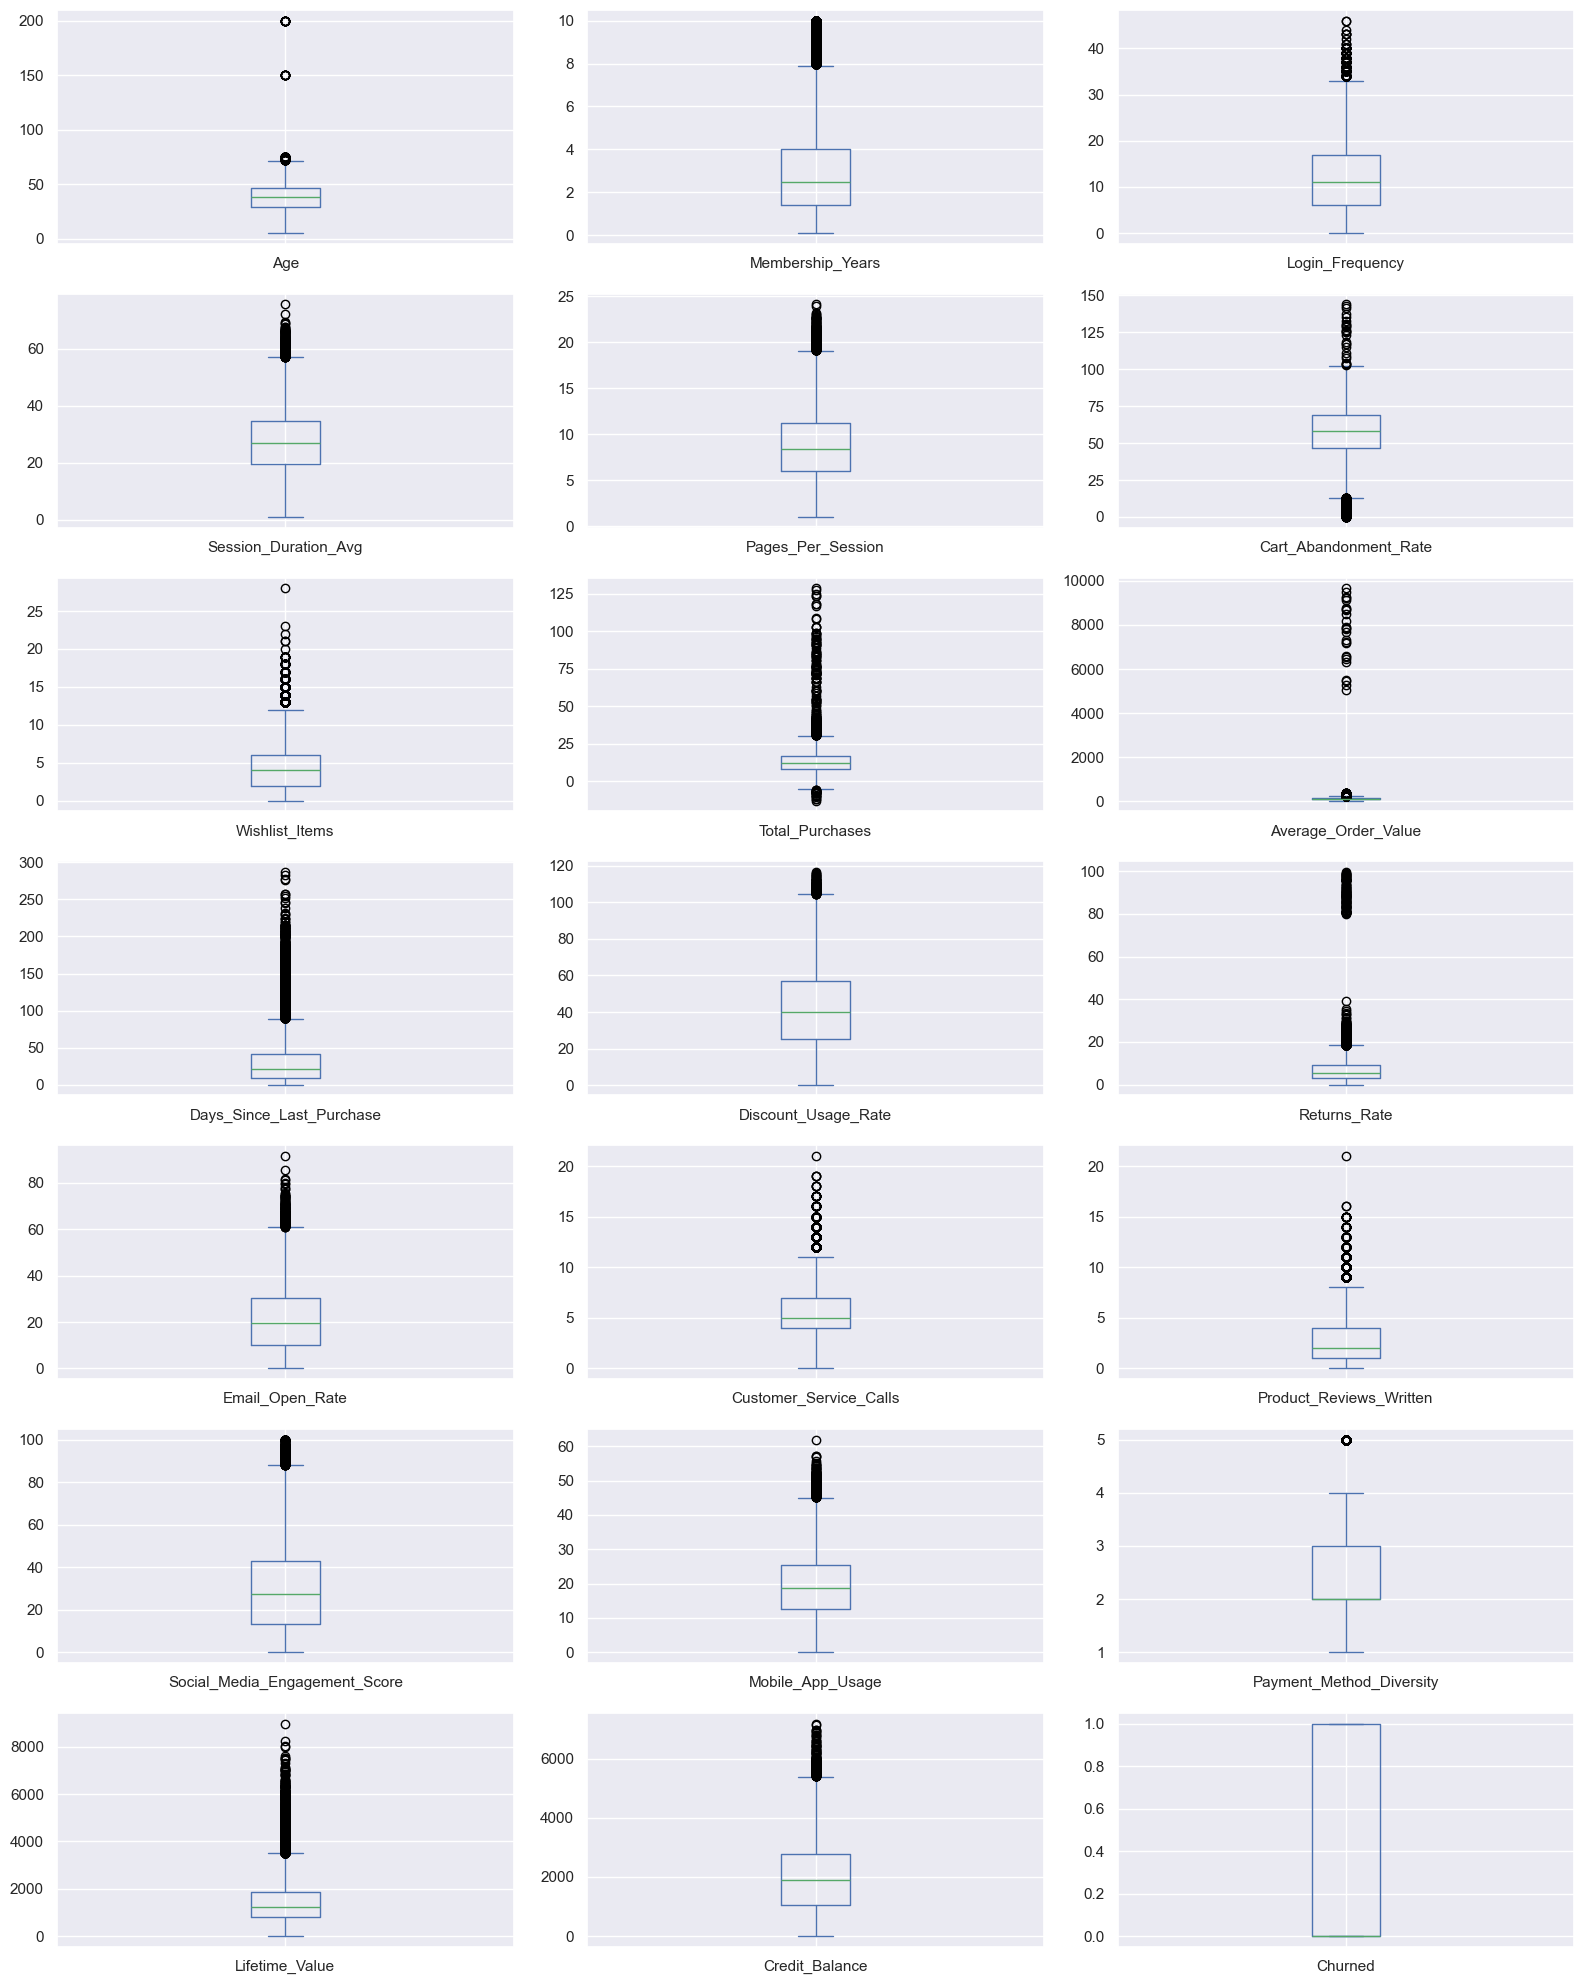

In [9]:
num_cols = dataset.select_dtypes(include=['float64', 'int64']).columns

# Single line me saare boxplots ek saath!
dataset[num_cols].plot(kind='box', subplots=True, layout=(7, 3), figsize=(16, 20), sharex=False)

plt.tight_layout()
plt.show()

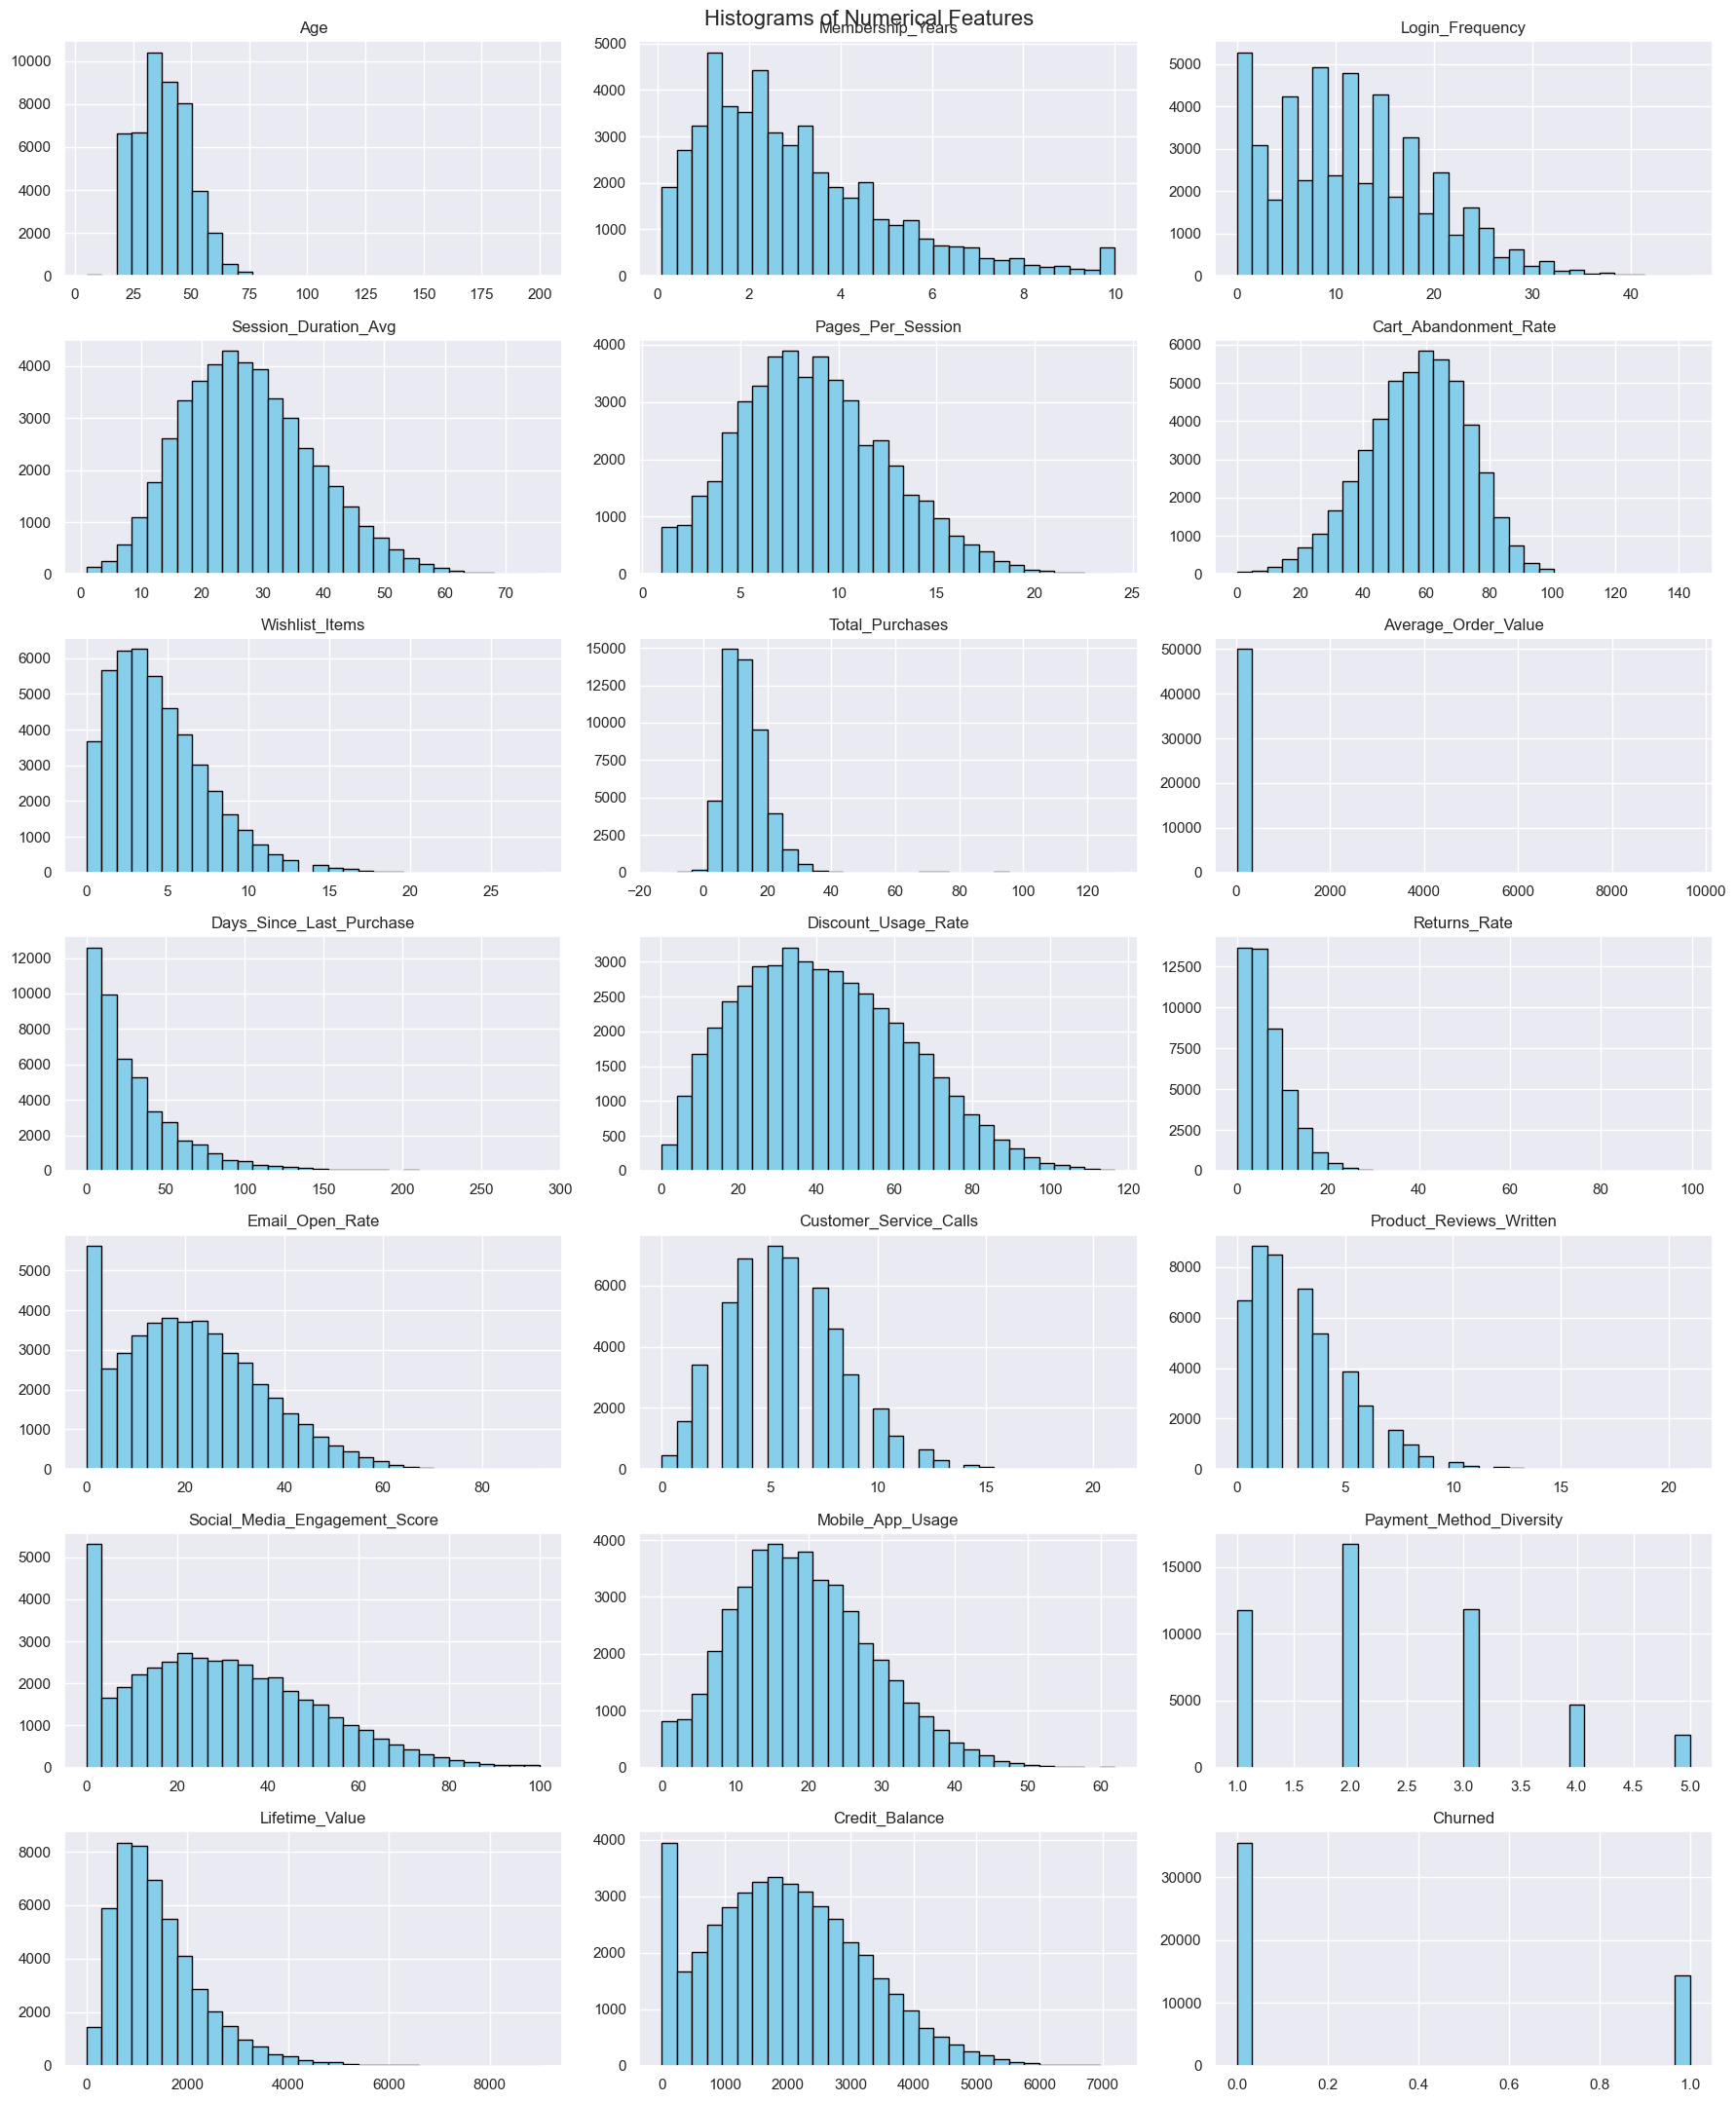

In [10]:
dataset[num_cols].hist(figsize=(18, 22), bins=30,  color='skyblue', edgecolor='black', layout=(7, 3))

plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

### 2. Data Cleaning & Missing Value Handling
We handle missing values by imputing continuous features with median values (to remain robust against outliers) and categorical features with the mode. Invalid entries or duplicates are also cleaned here to prepare the data for downstream tasks.

In [11]:
# -------------------------------
# Raw Dataset Validation
# -------------------------------

# Create mask for invalid values
invalid_mask = (
    # Total Purchases must be non-negative
    (
        dataset["Total_Purchases"].notna() &
        (dataset["Total_Purchases"] < 0)
    )

    |

    # Cart Abandonment Rate must be between 0 and 100
    (
        dataset["Cart_Abandonment_Rate"].notna() &
        ~dataset["Cart_Abandonment_Rate"].between(0, 100)
    )

    |

    # Returns Rate must be between 0 and 100
    (
        dataset["Returns_Rate"].notna() &
        ~dataset["Returns_Rate"].between(0, 100)
    )

    |

    # Discount Usage Rate must be between 0 and 100
    (
        dataset["Discount_Usage_Rate"].notna() &
        ~dataset["Discount_Usage_Rate"].between(0, 100)
    )

    |

    # Email Open Rate must be between 0 and 100
    (
        dataset["Email_Open_Rate"].notna() &
        ~dataset["Email_Open_Rate"].between(0, 100)
    )

    |

    # Age must be between 18 and 100
    (
        dataset["Age"].notna() &
        ~dataset["Age"].between(18, 100)
    )
)

# Count invalid rows
print("Invalid rows:", invalid_mask.sum())

# Remove only invalid rows
dataset = dataset[~invalid_mask].copy()

# Drop unhelpful columns
dataset = dataset.drop(
    columns=["City", "Signup_Quarter"],
    errors="ignore"
)

print("Shape after validation:", dataset.shape)

Invalid rows: 326
Shape after validation: (49674, 23)


In [12]:
features_with_nan = [features for features in dataset.columns if dataset[features].isnull().sum()>1]
for feature in features_with_nan:
    print(feature,dataset[feature].isnull().mean()*100 ,"%")

Age 4.992551435358537 %
Session_Duration_Avg 6.802351330676007 %
Pages_Per_Session 6.007166727060434 %
Wishlist_Items 7.994121673309981 %
Days_Since_Last_Purchase 6.003140475902887 %
Discount_Usage_Rate 7.029834521077424 %
Returns_Rate 8.972500704593953 %
Email_Open_Rate 5.052945202721746 %
Customer_Service_Calls 0.33216572049764465 %
Product_Reviews_Written 7.003663888553369 %
Social_Media_Engagement_Score 11.98212344486049 %
Mobile_App_Usage 10.003221000926038 %
Payment_Method_Diversity 5.018722067882594 %
Credit_Balance 10.989652534525103 %


In [13]:
# 1. Split your dataset BEFORE computing any summary statistics
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=['Churned'])
y = dataset['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------------
# 2. Categorical Columns: Fill using Mode computed ONLY from X_train
# ------------------------------------------------------------------
cat_cols_with_nan = [
    col for col in X_train.columns 
    if X_train[col].isnull().sum() > 0 and X_train[col].dtype == 'object'
]

for col in cat_cols_with_nan:
    # Compute mode on training set only
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# ------------------------------------------------------------------
# 3. Behavioral Numerical Columns: Fill with Constant (0)
# ------------------------------------------------------------------
zero_fill_cols = [
    'Customer_Service_Calls', 'Product_Reviews_Written', 'Wishlist_Items',
    'Discount_Usage_Rate', 'Returns_Rate', 'Mobile_App_Usage', 
    'Social_Media_Engagement_Score', 'Credit_Balance', 
    'Session_Duration_Avg', 'Pages_Per_Session', 'Email_Open_Rate'
]
zero_fill_cols = [col for col in zero_fill_cols if col in X_train.columns]

X_train[zero_fill_cols] = X_train[zero_fill_cols].fillna(0)
X_test[zero_fill_cols] = X_test[zero_fill_cols].fillna(0)

# ------------------------------------------------------------------
# 4. Special Case: Days Since Last Purchase (Fill with Constant 365)
# ------------------------------------------------------------------
if 'Days_Since_Last_Purchase' in X_train.columns:
    X_train['Days_Since_Last_Purchase'] = X_train['Days_Since_Last_Purchase'].fillna(365)
    X_test['Days_Since_Last_Purchase'] = X_test['Days_Since_Last_Purchase'].fillna(365)

# ------------------------------------------------------------------
# 5. Standard Numerical Columns: Fill using Median computed ONLY from X_train
# ------------------------------------------------------------------
num_cols_with_nan = [
    col for col in X_train.columns 
    if X_train[col].isnull().sum() > 0 and X_train[col].dtype != 'object'
]

for col in num_cols_with_nan:
    # Compute median on training set only
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Verify
print("Remaining Missing Values in X_train:", X_train.isnull().sum().sum())
print("Remaining Missing Values in X_test:", X_test.isnull().sum().sum())

Remaining Missing Values in X_train: 0
Remaining Missing Values in X_test: 0


### Missing Value Imputation Strategy

#### 1. Categorical Columns — Mode Imputation

* **Method:** Missing categorical values were imputed using the **mode** (most frequently occurring category) calculated from `X_train`.
* **Reasoning:** Categorical variables such as `Gender` cannot be meaningfully imputed using numerical statistics such as mean or median. Therefore, the most frequent category was used as the replacement value.

#### 2. Behavioral & Engagement Columns — Zero Imputation

* **Features:** `Customer_Service_Calls`, `Product_Reviews_Written`, `Wishlist_Items`, `Discount_Usage_Rate`, `Returns_Rate`, `Mobile_App_Usage`, `Social_Media_Engagement_Score`, `Credit_Balance`, `Session_Duration_Avg`, `Pages_Per_Session`, `Email_Open_Rate`.
* **Method:** Missing values were replaced with a constant value of `0`.
* **Reasoning:** For activity- and usage-related variables, zero can represent the absence of the corresponding activity. For example, zero reviews, zero support calls, or zero wishlist items can indicate that no such activity was recorded. This approach avoids introducing an artificial median level of activity.

#### 3. Recency — 365-Day Imputation

* **Feature:** `Days_Since_Last_Purchase`
* **Method:** Missing values were replaced with `365`.
* **Reasoning:** A missing value in this feature can indicate that recent purchase activity was not available. A value of `0` would incorrectly represent a purchase occurring very recently. Therefore, `365` was used as a conservative inactivity value to represent approximately one year since the last purchase.

#### 4. Standard Numerical Columns — Median Imputation

* **Method:** Missing numerical values were imputed using the **median** calculated strictly from `X_train`.
* **Reasoning:** The median is less sensitive to extreme values and outliers than the mean. Therefore, it provides a robust estimate for replacing missing values in standard numerical attributes such as `Age` and `Income`.

### Data Leakage Prevention

All imputation statistics, including the mode and median, were calculated using **only the training data (`X_train`)**. The same values were then applied to the test data (`X_test`). This prevents information from the test set from influencing the training process and helps maintain a reliable evaluation of model performance.


In [14]:
import numpy as np

cont_cols = X_train.select_dtypes(include=["float64", "int64"]).columns

for col in cont_cols:
    lower_bound = X_train[col].quantile(0.01)
    upper_bound = X_train[col].quantile(0.99)

    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

### Outlier Handling (Capping / Clipping)
To handle extreme outliers without removing valuable data rows, we apply **Winsorization (Capping)** at the 1st and 99th percentiles:

- **Quantile Thresholds:** Calculated strictly from `X_train` to prevent data leakage.
- **`np.clip()`:** Clips extreme low values below the 1st percentile to the 1st percentile mark, and extreme high values above the 99th percentile to the 99th percentile mark.
- **Reasoning:** Keeps all training data intact while preventing extreme values from skewing model learning.

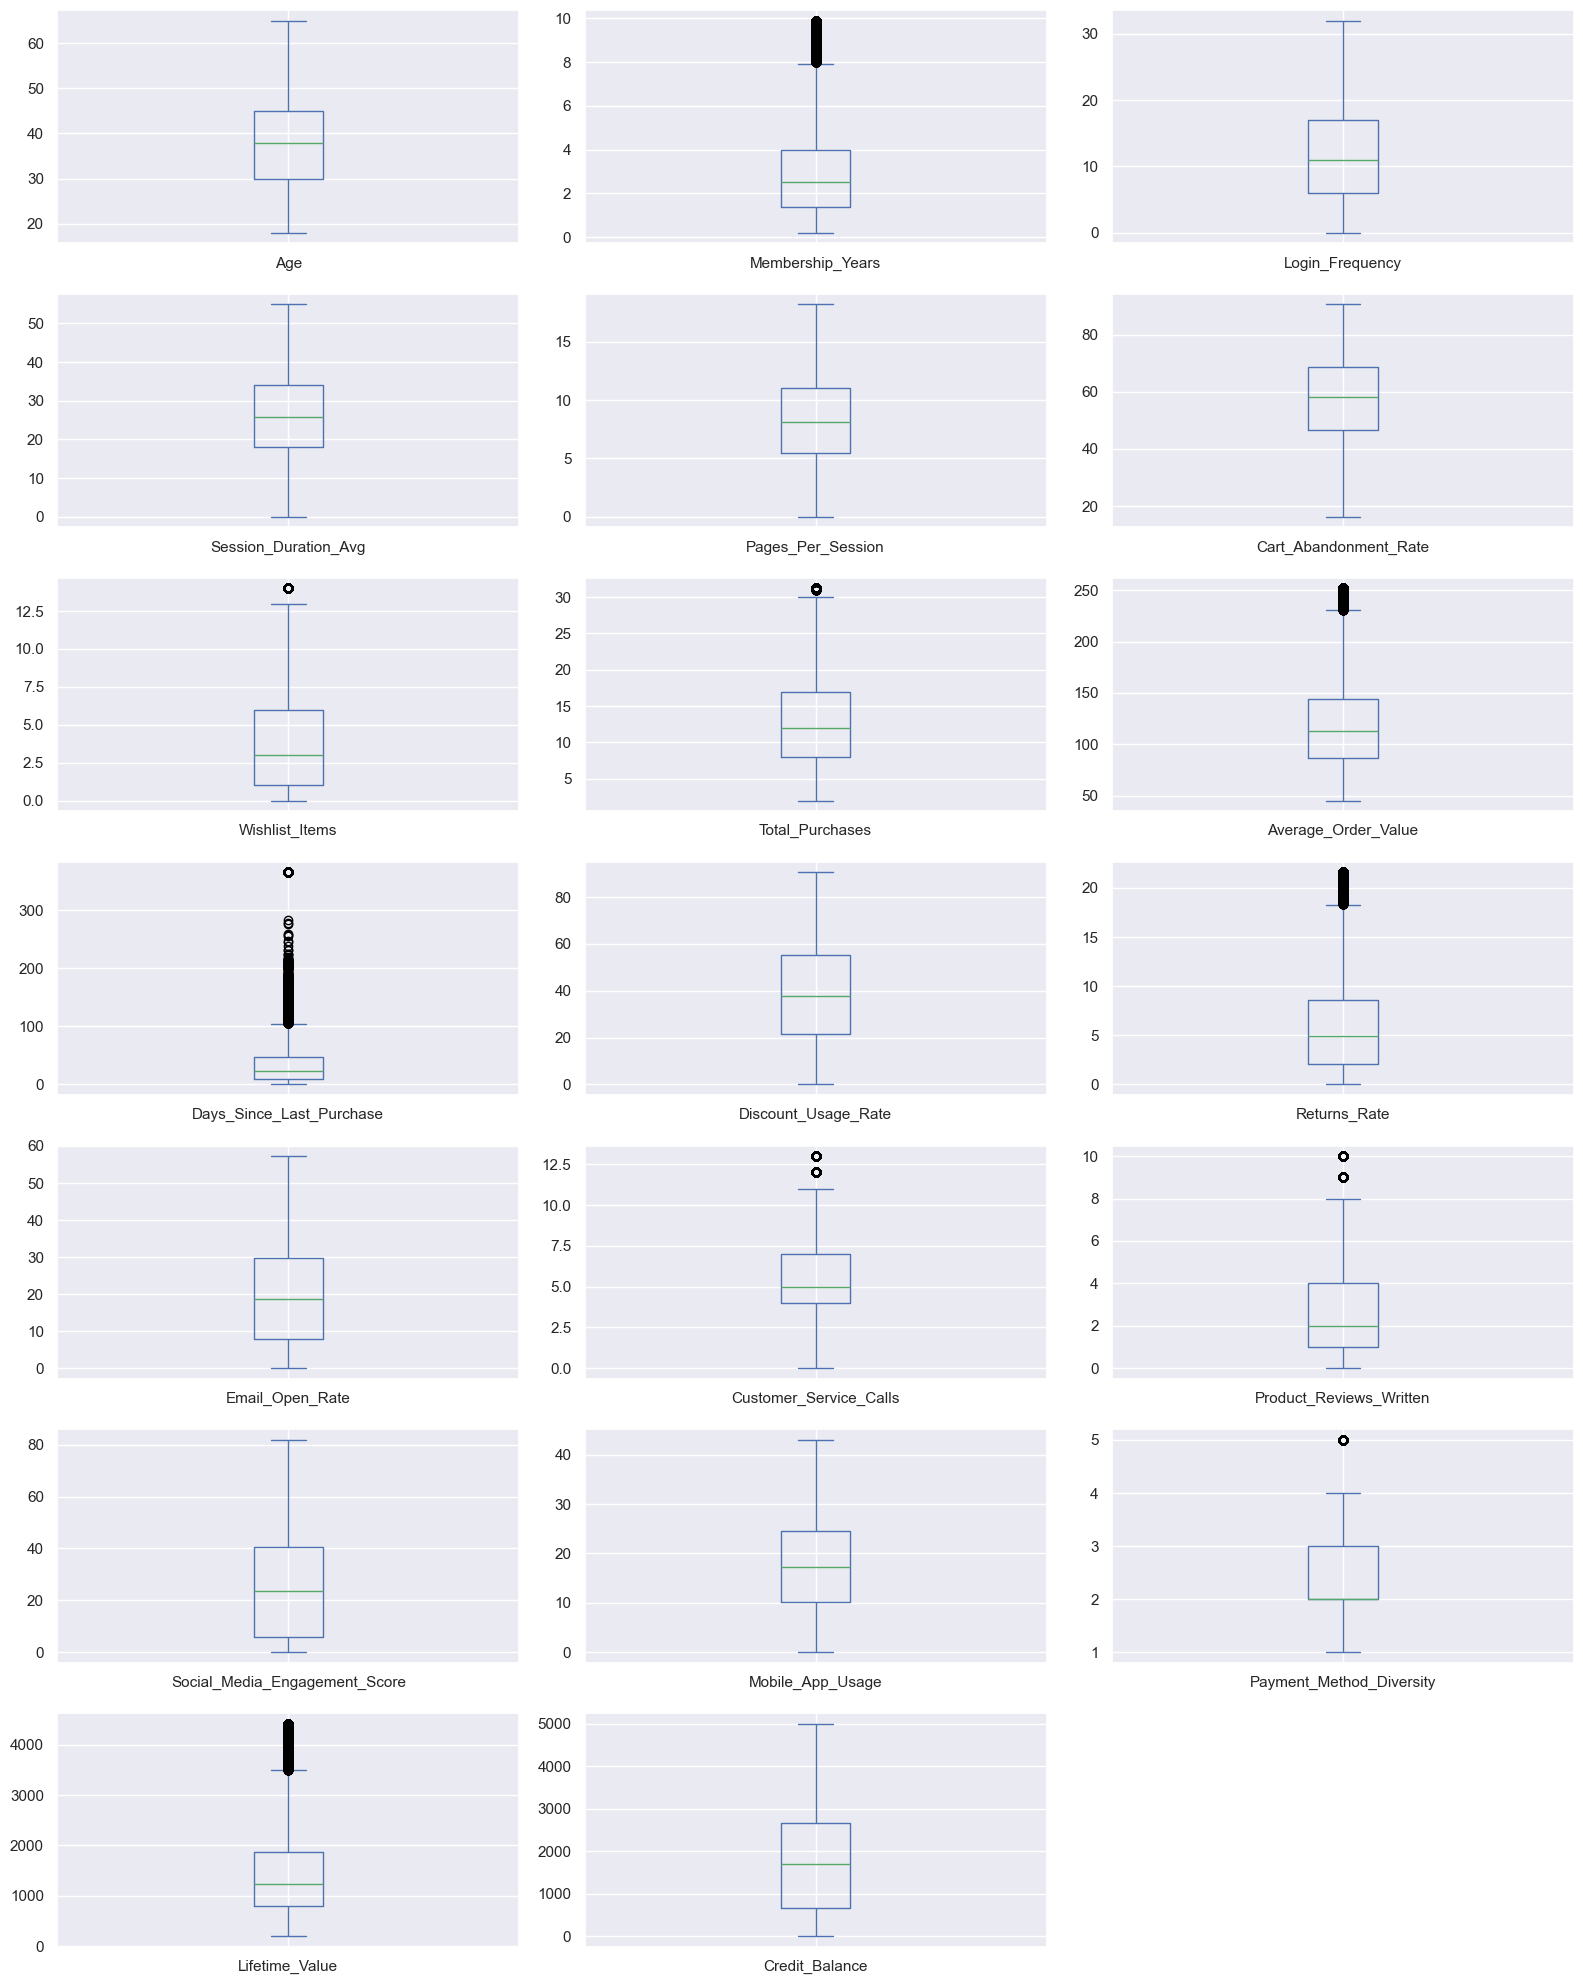

In [15]:
num_cols = dataset.select_dtypes(include=['float64', 'int64']).drop(columns=['Churned'], errors='ignore').columns

X_train[num_cols].plot(kind='box', subplots=True, layout=(7, 3), figsize=(16, 20), sharex=False)
plt.tight_layout()
plt.show()

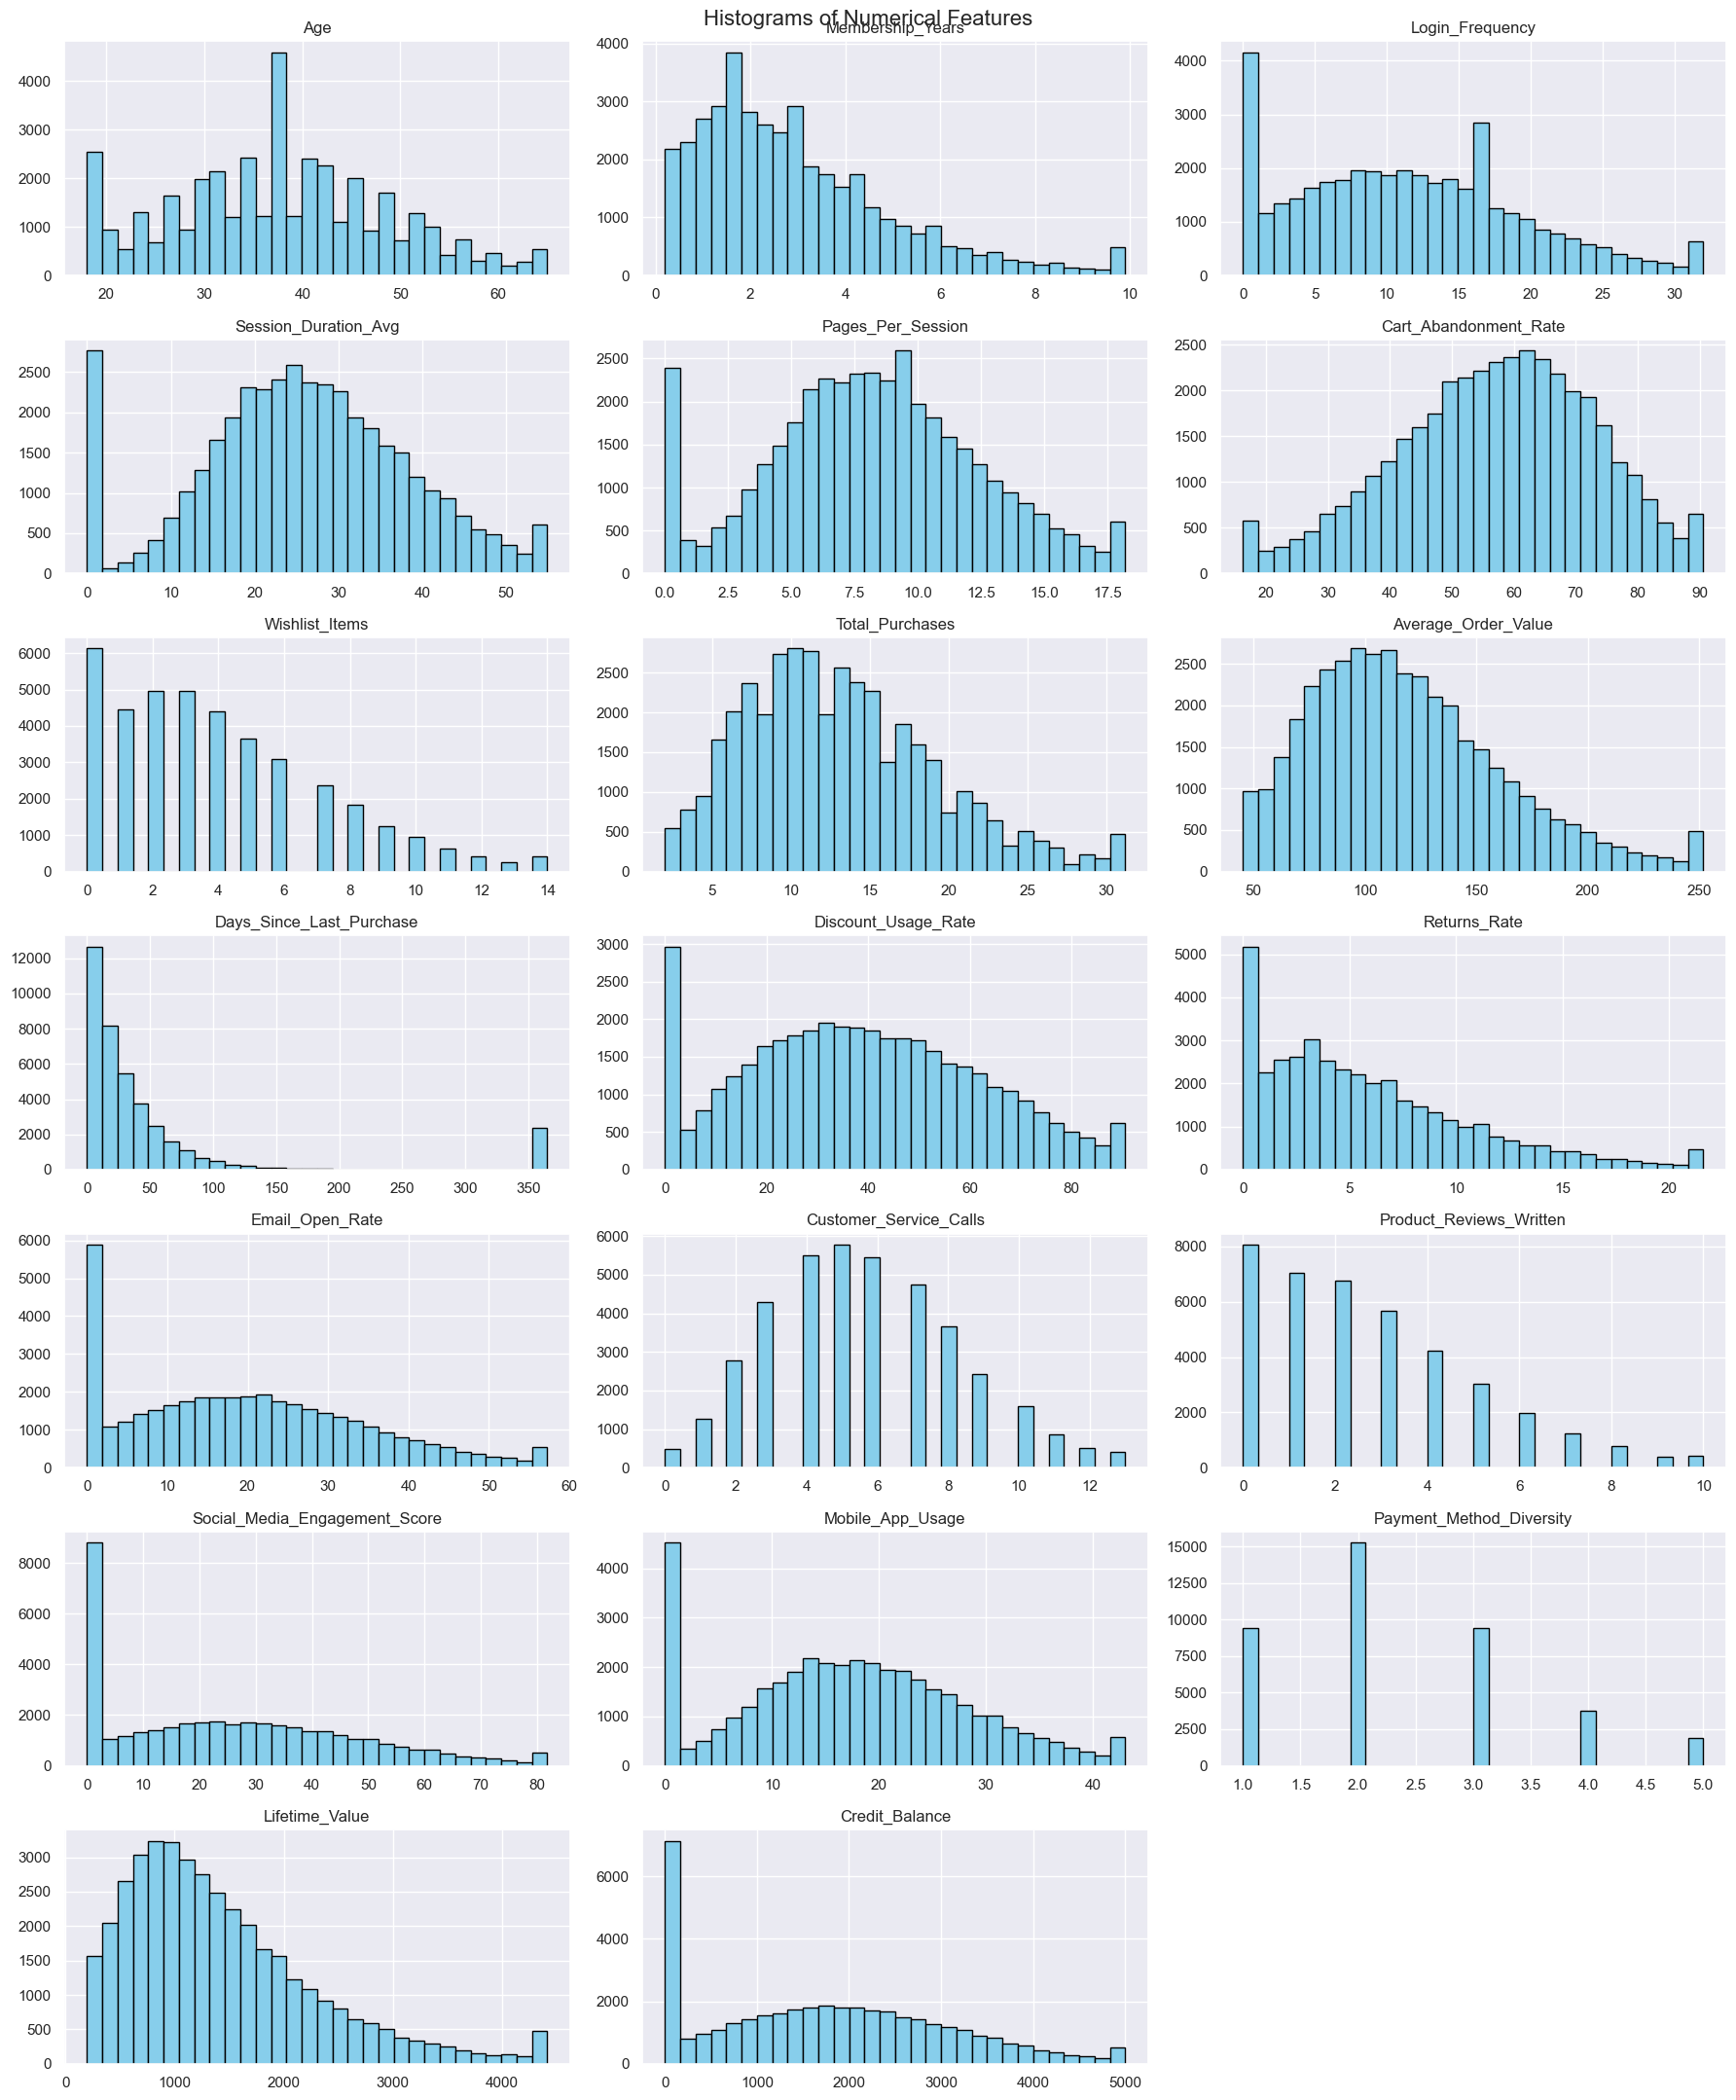

In [16]:
X_train[num_cols].hist(figsize=(18, 22), bins=30, color='skyblue', edgecolor='black', layout=(7, 3))

plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


In [17]:
dataset.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47194.000000,49674.000000,49674.000000,46295.000000,46690.000000,49674.000000,45703.000000,49674.000000,49674.000000,46692.000000,46182.000000,45217.000000,47164.000000,49509.000000,46195.000000,43722.000000,44705.000000,47181.000000,49674.000000,44215.000000,49674.000000
mean,37.762110,2.983319,11.627028,27.662501,8.739465,57.042207,4.298361,13.115604,123.111937,29.792641,41.722769,6.681039,20.938896,5.681654,2.853491,29.371735,19.371021,2.353490,1440.154063,1966.480787,0.288964
std,11.450844,2.058798,7.813059,10.871152,3.779000,16.216906,3.190245,6.997703,176.107861,29.695169,20.988929,6.152803,14.253194,2.676868,2.329414,20.582416,9.420637,1.109943,906.975622,1225.510857,0.453286
min,18.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.040000,9.000000,25.300000,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.332500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.920000,21.000000,40.100000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1242.945000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.420000,41.000000,56.800000,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1873.902500,2791.500000,1.000000
max,75.000000,10.000000,46.000000,75.600000,24.100000,100.000000,28.000000,128.700000,9666.379178,287.000000,99.960000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


## 3. Exploratory Data Analysis (EDA) & Business Insights
In this section, we analyze feature distributions, target class balance, and key behavioral patterns driving customer churn.

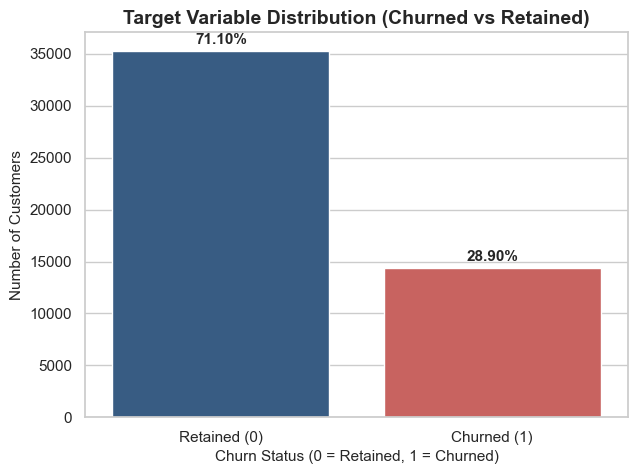

In [18]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Target Variable Plot
ax = sns.countplot(x='Churned', data=dataset, palette=['#2b5c8f', '#d9534f'])
plt.title('Target Variable Distribution (Churned vs Retained)', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])

# Add percentage annotations
total = len(dataset)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.show()

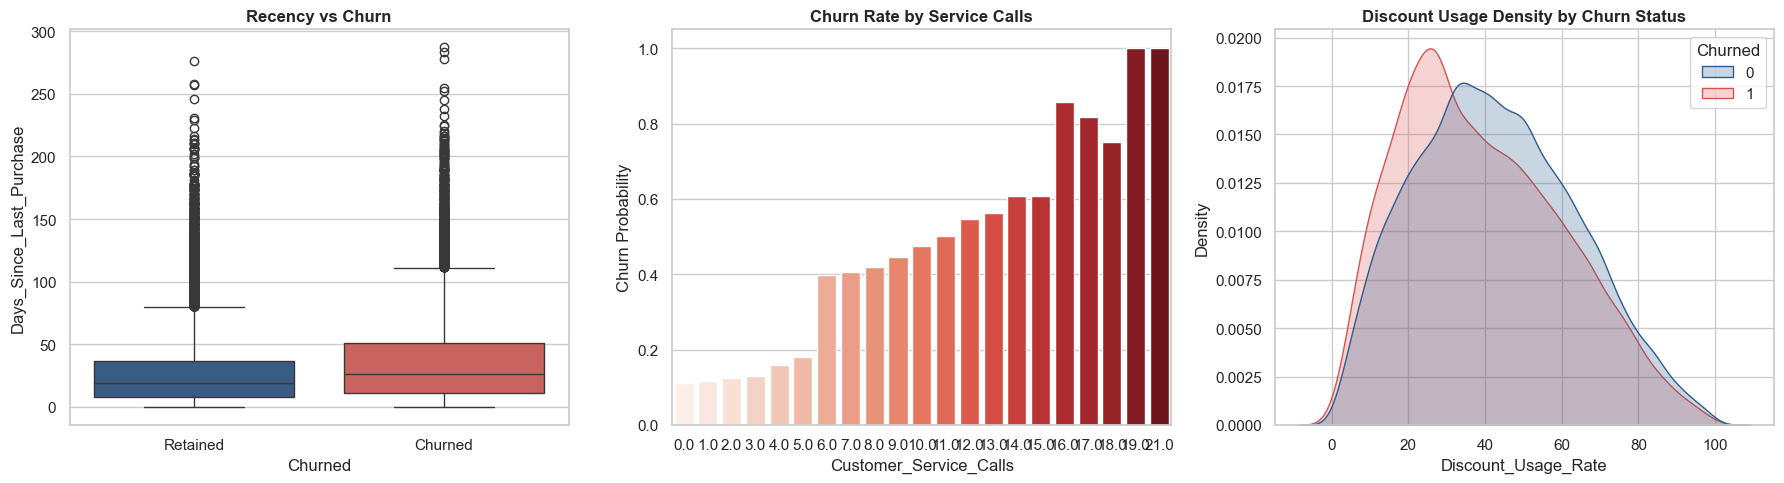

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Days Since Last Purchase vs Churn
sns.boxplot(ax=axes[0], x='Churned', y='Days_Since_Last_Purchase', data=dataset, palette=['#2b5c8f', '#d9534f'])
axes[0].set_title('Recency vs Churn', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Retained', 'Churned'])

# 2. Customer Service Calls vs Churn
sns.barplot(ax=axes[1], x='Customer_Service_Calls', y='Churned', data=dataset, ci=None, palette='Reds')
axes[1].set_title('Churn Rate by Service Calls', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Probability')

# 3. Discount Usage Rate vs Churn
sns.kdeplot(ax=axes[2], data=dataset, x='Discount_Usage_Rate', hue='Churned', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True)
axes[2].set_title('Discount Usage Density by Churn Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Behavioral Drivers of Churn Analysis

- **Recency vs Churn (Boxplot):** Retained customers show very low inactivity (median ~20–25 days), whereas churned customers exhibit much wider spreads and extreme inactivity periods (up to 300+ days), confirming recency as a key risk signal.
- **Customer Service Calls vs Churn (Bar Plot):** Churn probability increases drastically as support calls rise (reaching over 80–90% for high call volumes), highlighting unresolved user frustration as a direct driver of churn.
- **Discount Usage Rate (KDE Plot):** Retained customers have higher density around active discount usage, showing that promotional engagement helps retain users.

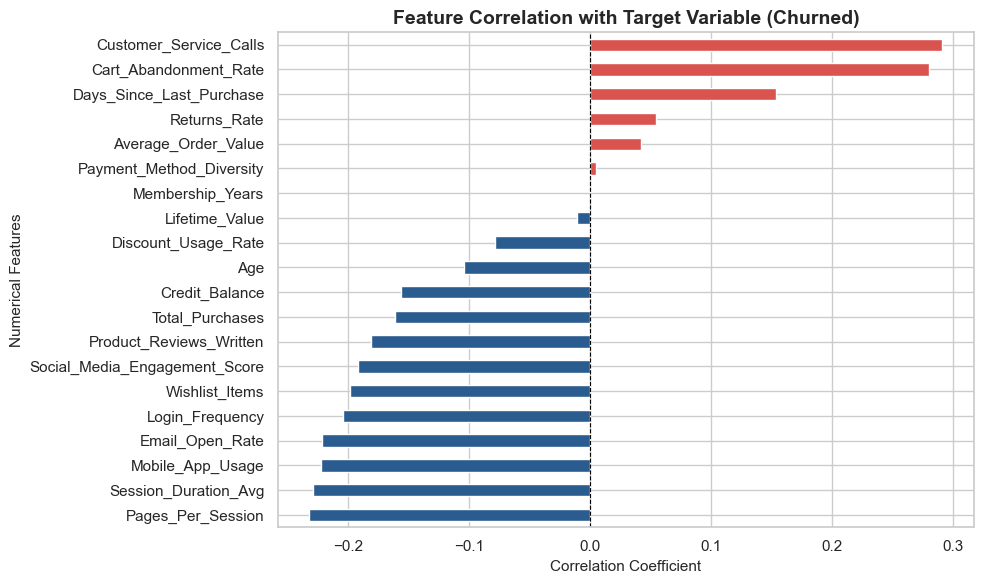

In [20]:
plt.figure(figsize=(10, 6))

# Calculate correlation with target
num_dataset = dataset.select_dtypes(include=['float64', 'int64'])
churn_corr = num_dataset.corr()['Churned'].drop('Churned').sort_values()

# Horizontal Bar Plot
churn_corr.plot(kind='barh', color=churn_corr.apply(lambda x: '#d9534f' if x > 0 else '#2b5c8f'))
plt.title('Feature Correlation with Target Variable (Churned)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.ylabel('Numerical Features', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

#### Feature Correlation Analysis with Churn Target

- **Top Positive Drivers (Increases Churn Risk):** `Customer_Service_Calls`, `Cart_Abandonment_Rate`, and `Days_Since_Last_Purchase` show the strongest positive correlation with churn, indicating that high support friction, checkout drop-offs, and prolonged inactivity directly drive churn.
- **Top Negative Drivers (Boosts Retention):** `Discount_Usage_Rate`, `Lifetime_Value`, and `Membership_Years` show negative correlation with churn, highlighting that long-term membership, higher spend, and promotional engagement strongly act as key retention signals.

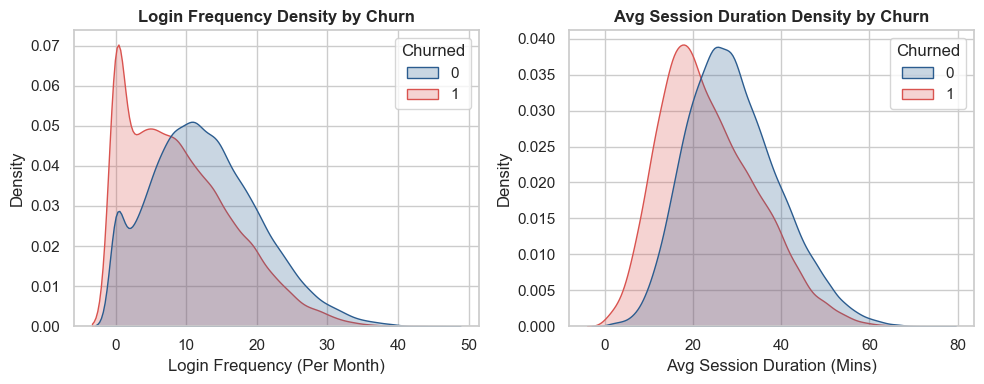

In [21]:
# Improved Bivariate EDA: Login Frequency Density
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(data=dataset, x='Login_Frequency', hue='Churned', fill=True, palette=['#2b5c8f', '#d9534f'], common_norm=False)
plt.title('Login Frequency Density by Churn', fontsize=12, fontweight='bold')
plt.xlabel('Login Frequency (Per Month)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=dataset, x='Session_Duration_Avg', hue='Churned', fill=True, palette=['#2b5c8f', '#d9534f'], common_norm=False)
plt.title('Avg Session Duration Density by Churn', fontsize=12, fontweight='bold')
plt.xlabel('Avg Session Duration (Mins)')

plt.tight_layout()
plt.show()

#### Customer Activity & Engagement Analysis (Login Frequency & Session Duration)

- **Login Frequency Density:** Retained customers show higher density around frequent monthly logins, whereas customers with low login activity exhibit a significantly higher churn rate.
- **Average Session Duration Density:** Churned customers tend to spend less time per session, indicating that lower engagement and low platform interaction are strong indicators of potential churn.

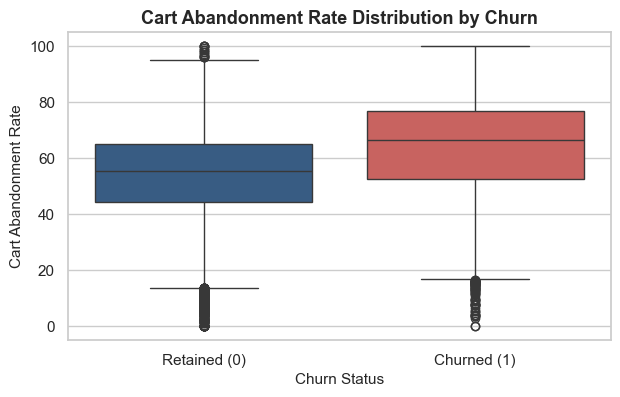

In [22]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Churned', y='Cart_Abandonment_Rate', data=dataset, palette=['#2b5c8f', '#d9534f'])
plt.title('Cart Abandonment Rate Distribution by Churn', fontsize=13, fontweight='bold')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.xlabel('Churn Status', fontsize=11)
plt.ylabel('Cart Abandonment Rate', fontsize=11)
plt.show()

#### Customer Activity & Engagement Analysis (Login Frequency & Session Duration)

- **Login Frequency Density:** Retained customers show higher density around frequent monthly logins, whereas customers with low login activity exhibit a significantly higher churn rate.
- **Average Session Duration Density:** Churned customers tend to spend less time per session, indicating that lower engagement and low platform interaction are strong indicators of potential churn.

In [23]:
def apply_feature_engineering(df):
    df = df.copy()
    # 1. Behavioral Ratios
    df["Recency_Ratio"] = df["Days_Since_Last_Purchase"] / (
        df["Membership_Years"] * 365 + 1
    )
    df["Value_Per_Purchase"] = df["Lifetime_Value"] / (
        df["Total_Purchases"] + 1
    )
    df["Support_Pressure"] = df["Customer_Service_Calls"] / (
        df["Total_Purchases"] + 1
    )

    # 2. Platform Engagement Metrics
    df["Session_Engagement"] = (
        df["Pages_Per_Session"] * df["Session_Duration_Avg"]
    )
    df["Review_To_Purchase_Ratio"] = df["Product_Reviews_Written"] / (
        df["Total_Purchases"] + 1
    )

    # 3. Customer Friction & Shopping Habits
    df["Return_Frequency_Value"] = df["Returns_Rate"] * df["Total_Purchases"]
    df["Cart_Abandonment_Severity"] = (
        df["Cart_Abandonment_Rate"] * df["Wishlist_Items"]
    )
    df["Wallet_Utilization"] = df["Credit_Balance"] / (
        df["Lifetime_Value"] + 1
    )

    # 4. Long-Term Customer Loyalty Indicators
    df["Platform_Stickiness"] = (
        df["Login_Frequency"] * df["Session_Duration_Avg"]
    )
    df["Loyalty_Velocity"] = df["Total_Purchases"] / (
        df["Membership_Years"] + 0.1
    )

    # 5. Log Transformations
    df["Log_Lifetime_Value"] = np.log1p(df["Lifetime_Value"])
    df["Log_Average_Order_Value"] = np.log1p(df["Average_Order_Value"])

    return df


# Apply to train and test sets
X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

###  Domain-Driven Feature Engineering

We create synthetic behavioral ratios and interaction terms to extract deeper business signals from raw customer attributes:

1. **Behavioral Ratios:**
   - **`Recency_Ratio`** (`Days_Since_Last_Purchase` / `Membership_Years * 365 + 1`): Measures inactivity relative to total tenure. A high ratio flags long-term users who suddenly became inactive.
   - **`Value_Per_Purchase`** (`Lifetime_Value` / `Total_Purchases + 1`): Represents Average Order Value (AOV) per transaction to capture purchasing power.
   - **`Support_Pressure`** (`Customer_Service_Calls` / `Total_Purchases + 1`): Captures support intensity per order. High values indicate strong friction or product dissatisfaction.

2. **Platform Engagement Metrics:**
   - **`Session_Engagement`** (`Pages_Per_Session` * `Session_Duration_Avg`): Quantifies total active engagement depth during visits.
   - **`Review_To_Purchase_Ratio`** (`Product_Reviews_Written` / `Total_Purchases + 1`): Measures customer advocacy and willingness to provide product feedback.

3. **Customer Friction & Shopping Habits:**
   - **`Return_Frequency_Value`** (`Returns_Rate` * `Total_Purchases`): Estimates the total volume of returns processed.
   - **`Cart_Abandonment_Severity`** (`Cart_Abandonment_Rate` * `Wishlist_Items`): Identifies high-intent buyers experiencing severe checkout friction.
   - **`Wallet_Utilization`** (`Credit_Balance` / `Lifetime_Value + 1`): Measures unspent store credit relative to overall historical spending.

4. **Long-Term Loyalty & Activity Velocity:**
   - **`Platform_Stickiness`** (`Login_Frequency` * `Session_Duration_Avg`): Combined monthly active time on the platform.
   - **`Loyalty_Velocity`** (`Total_Purchases` / `Membership_Years + 0.1`): Annual purchasing frequency, identifying accelerating or decelerating buyer behavior.

5. **Non-Linear Transformations:**
   - **`Log_Lifetime_Value` & `Log_Average_Order_Value`**: Log-transformed heavy right-skewed monetary values to stabilize feature variance for model learning.

### 4. Feature Preprocessing (Scaling & Encoding)
- **One-Hot Encoding:** Applied to non-ordinal categorical variables (like `Country`, `Gender`) so the algorithm can process them numerically without assuming any natural ordering.
- **Standard Scaling:** Continuous numerical features are scaled using `StandardScaler` to bring all values to a common range (mean = 0, standard deviation = 1). This ensures features with large numbers (like `Lifetime_Value`) do not dominate model learning over smaller numerical ranges.

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Identify Categorical Columns
cat_cols = ['Gender', 'Country']

# 2. Fit OneHotEncoder ONLY on X_train to avoid data leakage
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

# 3. Combine encoded categories back with numeric features
X_train_encoded = pd.concat([X_train.drop(columns=cat_cols), X_train_cat], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=cat_cols), X_test_cat], axis=1)

# 4. Feature Scaling (Fit on Train, Transform on Test)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print(f"Final Preprocessed X_train shape: {X_train_scaled.shape}")
print(f"Final Preprocessed X_test shape: {X_test_scaled.shape}")

Final Preprocessed X_train shape: (39739, 41)
Final Preprocessed X_test shape: (9935, 41)


### 5. Model Building & Baseline Selection

We import a diverse set of Classification Algorithms and Evaluation Metrics to evaluate initial performance on preprocessed data:
- **Linear & Distance-Based Models:** `LogisticRegression`, `KNeighborsClassifier`, `SVC`, `GaussianNB`.
- **Tree-Based Ensembles:** `DecisionTreeClassifier`, `RandomForestClassifier`, `AdaBoostClassifier`, `GradientBoostingClassifier`, `XGBClassifier`.
- **Evaluation Metrics:** Evaluated using **Accuracy, Precision, Recall, F1-Score**, and **ROC-AUC** to assess both class accuracy and continuous probability ranking power.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [26]:
models = {
    "Logisitic Regression": LogisticRegression(random_state=42),
    "KNN Classifier": KNeighborsClassifier(),
    "Navie Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(max_depth=8, random_state=42),
    "Xgboost": XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)  # Train model

    # Hard predictions for class metrics
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Soft probabilities for ROC-AUC
    y_train_probs = model.predict_proba(X_train_scaled)[:, 1]
    y_test_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    # Fixed: Now using y_train and y_train_probs
    model_train_rocauc_score = roc_auc_score(y_train, y_train_probs)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_probs)

    print(name)
    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print("- F1 score: {:.4f}".format(model_train_f1))
    print("- Precision: {:.4f}".format(model_train_precision))
    print("- Recall: {:.4f}".format(model_train_recall))
    print("- Roc Auc Score: {:.4f}".format(model_train_rocauc_score))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(model_test_accuracy))
    print("- F1 score: {:.4f}".format(model_test_f1))
    print("- Precision: {:.4f}".format(model_test_precision))
    print("- Recall: {:.4f}".format(model_test_recall))
    print("- Roc Auc Score: {:.4f}".format(model_test_rocauc_score))

    print("=" * 35)
    print("\n")

Logisitic Regression
Model performance for Training set
- Accuracy: 0.7888
- F1 score: 0.5631
- Precision: 0.6998
- Recall: 0.4710
- Roc Auc Score: 0.8033
----------------------------------
Model performance for Test set
- Accuracy: 0.7896
- F1 score: 0.5662
- Precision: 0.7006
- Recall: 0.4751
- Roc Auc Score: 0.8068


KNN Classifier
Model performance for Training set
- Accuracy: 0.8420
- F1 score: 0.6753
- Precision: 0.8313
- Recall: 0.5686
- Roc Auc Score: 0.9042
----------------------------------
Model performance for Test set
- Accuracy: 0.7782
- F1 score: 0.5281
- Precision: 0.6854
- Recall: 0.4295
- Roc Auc Score: 0.7633


Navie Bayes
Model performance for Training set
- Accuracy: 0.6737
- F1 score: 0.5291
- Precision: 0.4538
- Recall: 0.6343
- Roc Auc Score: 0.7140
----------------------------------
Model performance for Test set
- Accuracy: 0.6847
- F1 score: 0.5414
- Precision: 0.4669
- Recall: 0.6440
- Roc Auc Score: 0.7208


SVM
Model performance for Training set
- Accuracy

#### 5.1 Baseline Model Performance Comparison
We train multiple algorithms using cross-evaluation on both Training and Test sets to identify optimal performance and monitor overfitting:

- **Overfitting Control:** Constrained tree depths for Decision Tree (`max_depth=6`) and Random Forest (`max_depth=8`) ensure tight alignment between training and testing metrics.
- **Top Performing Baseline:** **XGBoost** demonstrates superior class separation out of the box (**Test Accuracy: 91.71%**, **ROC-AUC: 0.9269**).
- **Metric Priority:** Since churn prediction prioritizes catching potential churners while minimizing false alarms, **ROC-AUC** and **F1-Score** are used as primary selection criteria for model tuning.

### 6. Hyperparameter Optimization (XGBoost)
Instead of relying on default parameters, we use `RandomizedSearchCV` with 5-fold cross-validation across 20 iteration samples to discover the best parameter combination efficiently:

- **`n_estimators` (100 to 300):** Defines the number of boosted trees to build.
- **`max_depth` (3 to 8):** Limits tree depth to control model complexity and prevent overfitting.
- **`learning_rate` (0.01 to 0.21):** Shrinks the step size of each iteration to make learning stable.
- **`subsample` & `colsample_bytree` (0.7 to 1.0):** Samples a random fraction of rows and features for each tree, introducing stochasticity to prevent overfitting.
- **`min_child_weight` (1 to 6):** Sets a minimum instance weight needed in a leaf node to control tree splitting.
- **`eval_metric='logloss'`:** Guides optimization by penalizing inaccurate probability predictions.
- **`scoring='roc_auc'`:** Focuses tuning on maximizing overall class separation quality.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# Parameter distributions defined
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(1, 6)
}

# 20 random combinations evaluated (fast & accurate)
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

# Best Model extracted
best_xgb_model = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

Best Hyperparameters: {'colsample_bytree': np.float64(0.935552788417904), 'learning_rate': np.float64(0.04993475643167195), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 230, 'subsample': np.float64(0.9579821220208962)}


In [ ]:
from sklearn.metrics import classification_report

# 1. Use ready-made best trained model from RandomizedSearch
best_xgb_model = random_search.best_estimator_

# 2. Extract predicted probabilities for class 1 (Churned)
y_probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# 3. Apply custom threshold (0.35)
custom_threshold = 0.35
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 4. Final Classification Report
print(f"--- Tuned XGBoost Performance at Threshold {custom_threshold} ---")
print(classification_report(y_test, y_pred_custom))

--- Tuned XGBoost Performance at Threshold 0.35 ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      7064
           1       0.87      0.85      0.86      2871

    accuracy                           0.92      9935
   macro avg       0.90      0.90      0.90      9935
weighted avg       0.92      0.92      0.92      9935



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 1. RandomizedSearch extracts best model
best_xgb = random_search.best_estimator_

# 2. Hard predictions (Accuracy, Precision, Recall, F1 Score)
y_train_pred = best_xgb.predict(X_train_scaled)
y_test_pred = best_xgb.predict(X_test_scaled)

# 3. Soft probabilities (ROC-AUC Score)
y_train_probs = best_xgb.predict_proba(X_train_scaled)[:, 1]
y_test_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 4. Training metrics 
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_probs)

# 5. Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_probs)

# 6. Exact same format print statement
print("Xgboost")
print("Model performance for Training set")
print(f"- Accuracy: {train_acc:.4f}")
print(f"- F1 score: {train_f1:.4f}")
print(f"- Precision: {train_prec:.4f}")
print(f"- Recall: {train_rec:.4f}")
print(f"- Roc Auc Score: {train_auc:.4f}")

print("----------------------------------")

print("Model performance for Test set")
print(f"- Accuracy: {test_acc:.4f}")
print(f"- F1 score: {test_f1:.4f}")
print(f"- Precision: {test_prec:.4f}")
print(f"- Recall: {test_rec:.4f}")
print(f"- Roc Auc Score: {test_auc:.4f}")

print("===================================")

Xgboost
Model performance for Training set
- Accuracy: 0.9424
- F1 score: 0.8937
- Precision: 0.9581
- Recall: 0.8374
- Roc Auc Score: 0.9713
----------------------------------
Model performance for Test set
- Accuracy: 0.9225
- F1 score: 0.8566
- Precision: 0.9207
- Recall: 0.8008
- Roc Auc Score: 0.9289


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 1. Best model 
best_xgb = random_search.best_estimator_

# 2. Hard predictions with Custom Threshold (0.35) - CHANGE HERE
y_train_pred = (best_xgb.predict_proba(X_train_scaled)[:, 1] >= 0.35).astype(int)
y_test_pred = (best_xgb.predict_proba(X_test_scaled)[:, 1] >= 0.35).astype(int)

# 3. Soft probabilities (ROC-AUC Score same )
y_train_probs = best_xgb.predict_proba(X_train_scaled)[:, 1]
y_test_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 4. Training metrics 
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_probs)

# 5. Test metrics 
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_probs)

# 6. Print statement
print("Xgboost (At Threshold 0.35)")
print("Model performance for Training set")
print(f"- Accuracy: {train_acc:.4f}")
print(f"- F1 score: {train_f1:.4f}")
print(f"- Precision: {train_prec:.4f}")
print(f"- Recall: {train_rec:.4f}")
print(f"- Roc Auc Score: {train_auc:.4f}")

print("----------------------------------")

print("Model performance for Test set")
print(f"- Accuracy: {test_acc:.4f}")
print(f"- F1 score: {test_f1:.4f}")
print(f"- Precision: {test_prec:.4f}")
print(f"- Recall: {test_rec:.4f}")
print(f"- Roc Auc Score: {test_auc:.4f}")

print("===================================")

Xgboost (At Threshold 0.35)
Model performance for Training set
- Accuracy: 0.9408
- F1 score: 0.8953
- Precision: 0.9148
- Recall: 0.8766
- Roc Auc Score: 0.9713
----------------------------------
Model performance for Test set
- Accuracy: 0.9181
- F1 score: 0.8566
- Precision: 0.8664
- Recall: 0.8471
- Roc Auc Score: 0.9289


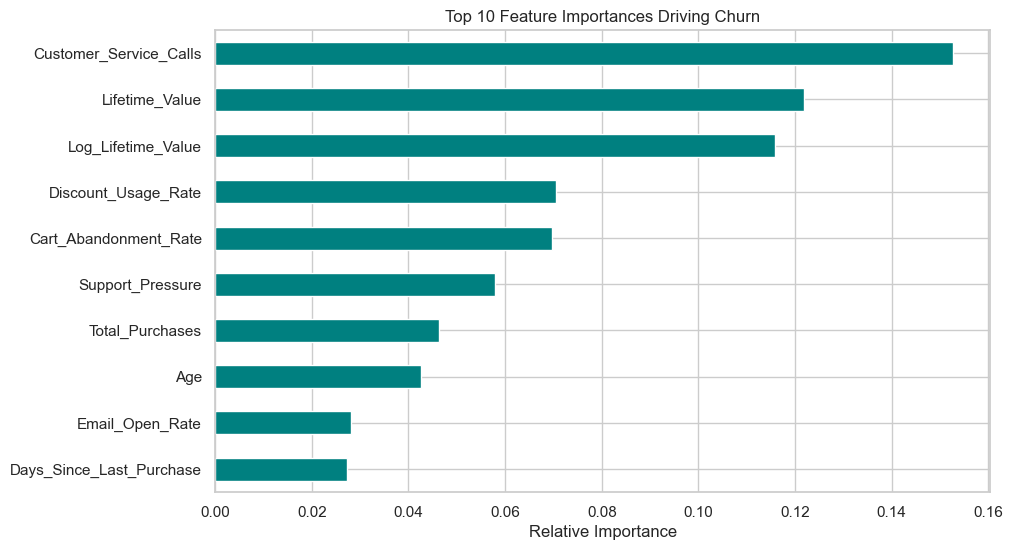

In [31]:
# Extract feature importances from tuned XGBoost
importances = pd.Series(best_xgb.feature_importances_, index=X_train_scaled.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances Driving Churn')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

<Figure size 600x500 with 0 Axes>

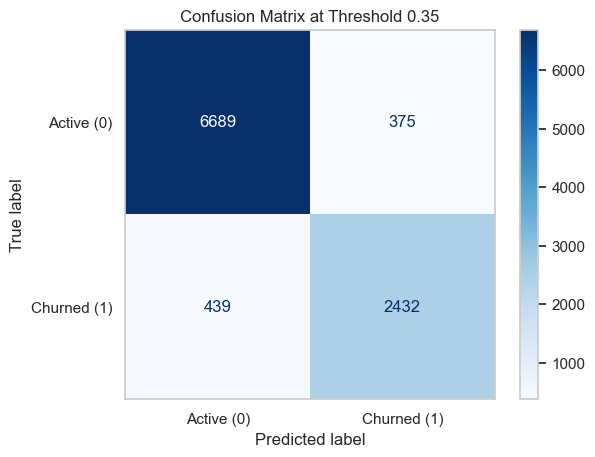

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active (0)', 'Churned (1)'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix at Threshold 0.35')
plt.grid(False)
plt.show()

###  Model Evaluation: Confusion Matrix Analysis (Threshold = 0.35)

To evaluate the performance of the tuned **XGBoost Classifier**, the confusion matrix was analyzed using a decision threshold of **0.35** instead of the default 0.50. At this threshold, the model achieved a **Recall of 84.71%**, **Precision of 86.64%**, and an **F1-Score of 85.66%** on the test data.

#### Key Findings from the Matrix:

* **True Positives (TP):** A high number of actual churned customers are correctly identified by the model, contributing to the improved recall at the selected threshold.

* **False Negatives (FN):** False negatives represent customers who actually churn but are predicted as active. Since missing potential churners can reduce the effectiveness of retention efforts, minimizing false negatives is an important objective for this problem.

* **False Positives (FP):** False positives represent active customers who are incorrectly classified as potential churners. Although these predictions may result in some unnecessary retention efforts, they can be considered acceptable when the objective is to identify as many potential churners as possible.

* **Recall:** The recall of **84.71%** indicates that the model successfully identifies a large proportion of the actual churned customers in the test set.

#### Strategic Alignment:

The use of a **0.35 decision threshold** places greater emphasis on identifying potential churners. This is suitable for a churn prediction problem where failing to identify a customer who is likely to churn may be more undesirable than incorrectly flagging an active customer.

Therefore, the selected threshold provides a practical balance between **Precision (86.64%) and Recall (84.71%)**, while maintaining a strong overall **F1-Score of 85.66%**.


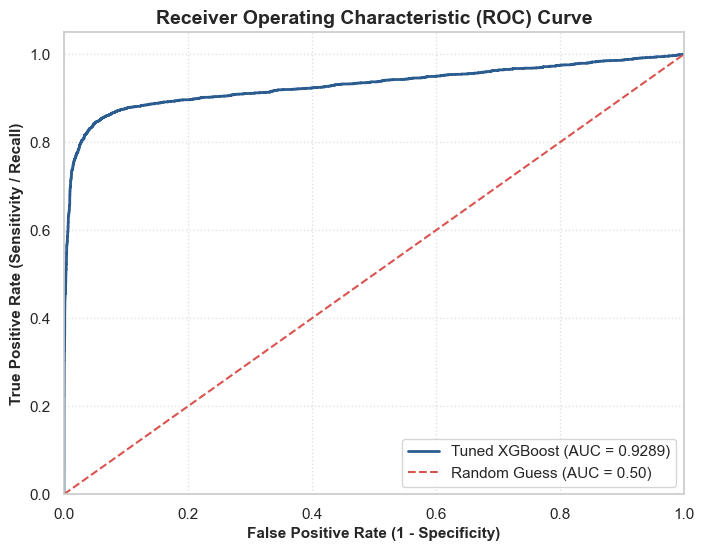

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate probabolities from best XGboost model
y_test_probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Dynamic ROC Score 
xgb_auc = roc_auc_score(y_test, y_test_probs)

# 3. False Positive Rate (FPR) & True Positive Rate (TPR) 
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)

# 4. ROC Curve Plot 
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2b5c8f', lw=2, label=f'Tuned XGBoost (AUC = {xgb_auc:.4f})')

# Baseline / Random Classifier Line (Red Diagonal)
plt.plot([0, 1], [0, 1], color='#d9534f', linestyle='--', label='Random Guess (AUC = 0.50)')

# Graph Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Graph save 
plt.savefig("xgb_roc_auc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
import joblib

# 1. Define deployment bundle (Ensure variable names match your environment)
deployment_artifacts = {
    'model': best_xgb_model,           # Verify your variable name (best_xgb vs best_xgb_model)
    'scaler': scaler,
    'ohe': ohe,
    'optimal_threshold': 0.35,
    'feature_names': list(X_train_scaled.columns)
}

# 2. Save pipeline
joblib.dump(deployment_artifacts, '1_Customer_churn_pipeline.pkl')
print("Tuned model and preprocessing artifacts saved successfully to Customer_churn_pipeline.pkl!")

Tuned model and preprocessing artifacts saved successfully to Customer_churn_pipeline.pkl!


###  Customer Risk Segmentation
To turn model outputs into actionable business strategy, we segment customers into three distinct risk tiers based on predicted churn probabilities:
- **High Risk ($\ge 0.60$):** Immediate high-priority retention intervention required (e.g., direct calls, exclusive discounts).
- **Medium Risk ($0.35 \text{ to } 0.60$):** Automated re-engagement campaigns (e.g., targeted email newsletters, product recommendations).
- **Low Risk ($< 0.35$):** Standard engagement strategy with low marketing overhead.

In [ ]:
# 1. Test set ke predictions and probabilities extract 
test_results = X_test_scaled.copy()
test_results['Actual_Churn'] = y_test
test_results['Predicted_Probability'] = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 2. Risk Tiers Assignment based on predicted churn probabilities
# High Risk: >= 0.60 | Medium Risk: 0.35 to 0.60 | Low Risk: < 0.35
conditions = [
    (test_results['Predicted_Probability'] >= 0.60),
    (test_results['Predicted_Probability'] >= 0.35) & (test_results['Predicted_Probability'] < 0.60),
    (test_results['Predicted_Probability'] < 0.35)
]
choices = ['High Risk', 'Medium Risk', 'Low Risk']

test_results['Risk_Segment'] = np.select(conditions, choices, default='Low Risk')

# 3. Risk Segment Summary Table (Business Insights)
risk_summary = test_results.groupby('Risk_Segment').agg(
    Total_Customers=('Actual_Churn', 'count'),
    Actual_Churners=('Actual_Churn', 'sum'),
    Actual_Churn_Rate=('Actual_Churn', 'mean'),
    Avg_Predicted_Prob=('Predicted_Probability', 'mean')
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])

risk_summary['Actual_Churn_Rate'] = (risk_summary['Actual_Churn_Rate'] * 100).round(2).astype(str) + '%'
risk_summary['Avg_Predicted_Prob'] = (risk_summary['Avg_Predicted_Prob'] * 100).round(2).astype(str) + '%'

print("=== Customer Churn Risk Segmentation Summary ===")
display(risk_summary)

=== Customer Churn Risk Segmentation Summary ===


,Total_Customers,Actual_Churners,Actual_Churn_Rate,Avg_Predicted_Prob
Risk_Segment,,,,
High Risk,2298,2180,94.87%,91.35%
Medium Risk,509,252,49.51%,47.1%
Low Risk,7128,439,6.16%,7.43%


## 7. Strategic Business Recommendations

Based on the model's risk segmentation outputs, we recommend the following targeted action items:

---

### 🚨 1. High Risk Segment ($\ge 0.60$ Churn Probability)
* **Strategy:** Immediate Retention Intervention
* **Actionable Steps:**
  * Escalate high-value accounts to customer success reps for immediate follow-up.
  * Offer high-value retention incentives (e.g., 20% renewal discount, free upgraded plan tier).

---

### ⚠️ 2. Medium Risk Segment ($0.35 \text{ to } 0.60$ Churn Probability)
* **Strategy:** Automated Targeted Re-Engagement Campaign
* **Actionable Steps:**
  * Send personalized email campaigns highlighting under-utilized features or new product updates.
  * Deliver targeted product recommendations based on past purchase history.

---

### 🟢 3. Low Risk Segment ($< 0.35$ Churn Probability)
* **Strategy:** Standard Engagement & Loyalty Strategy
* **Actionable Steps:**
  * Maintain low marketing overhead with automated newsletters and standard promotions.
  * Invite satisfied users into advocacy, referral, or loyalty programs.

## Model Performance Comparison

| Model                        | Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) | ROC-AUC (%) |
| ---------------------------- | -----------: | ------------: | ---------: | -----------: | ----------: |
| Logistic Regression          |        78.96 |         70.06 |      47.51 |        56.62 |       80.68 |
| K-Nearest Neighbors (KNN)    |        77.82 |         68.54 |      42.95 |        52.81 |       76.33 |
| Naive Bayes                  |        68.47 |         46.69 |      64.40 |        54.14 |       72.08 |
| Support Vector Machine (SVM) |        85.51 |         83.99 |      61.58 |        71.06 |       89.33 |
| Decision Tree                |        88.21 |         88.36 |      68.20 |        76.98 |       90.39 |
| Random Forest                |        87.22 |         90.37 |      62.42 |        73.84 |       91.41 |
| **XGBoost**                  |    **91.71** |     **90.89** |  **79.24** |    **84.67** |   **92.69** |

### Observation

Among all the evaluated models, **XGBoost achieved the best overall performance**, with the highest accuracy, recall, F1-score, and ROC-AUC. Therefore, XGBoost was selected for further hyperparameter tuning and threshold optimization.


# 8. Conclusion

This project developed a machine learning-based **E-Commerce Customer Churn Prediction System** using a synthetic customer behavior dataset. The dataset contained demographic, engagement, transactional, and behavioral information that was analyzed to identify patterns associated with customer churn.

The project followed a complete machine learning workflow, including **data validation, missing-value handling, exploratory data analysis, feature engineering, categorical encoding, feature scaling, model development, and model evaluation**. Multiple machine learning algorithms were evaluated, including Logistic Regression, KNN, Naive Bayes, SVM, Decision Tree, Random Forest, and XGBoost.

Among the evaluated models, **XGBoost achieved the best overall performance**. After hyperparameter tuning and threshold adjustment, the final model achieved approximately **91.81% accuracy, 86.64% precision, 84.71% recall, 85.66% F1-score, and 92.89% ROC-AUC** on the test data.

The project also introduced **customer risk segmentation** based on predicted churn probability, allowing customers to be categorized into low-, medium-, and high-risk groups. This can help demonstrate how machine learning predictions can support customer retention strategies.

## Limitations

The dataset used in this project is **synthetic** and does not represent actual customer records from a real e-commerce company. Therefore, the obtained performance metrics should not be interpreted as guaranteed real-world performance. The relationships identified by the model are specific to the patterns present in the synthetic dataset.

For future work, the model can be evaluated on a **real-world customer dataset** and further enhanced using model explainability techniques, deployment through a web application, and additional business-oriented analysis.

Overall, the project demonstrates the application of machine learning techniques to a customer churn prediction problem and provides a foundation for developing a more robust real-world customer retention system.
